In [ ]:
import sys, os
from pathlib import Path

project_root = Path("code").resolve()
sys.path.append(str(project_root))

print(project_root)

In [ ]:
import os
import logging
import time
import glob

import numpy as np
import pandas as pd
import math
import tqdm
import torch
import torch.utils.data as data
import os
from typing import Tuple, Union

import numpy as np
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T

In [ ]:

from models.diffusion import Model
from models.ema import EMAHelper
from functions import get_optimizer
from functions.p_losses import loss_registry
from skimage.metrics import structural_similarity as ssim
import torchvision.utils as tvu
import torchvision
from PIL import Image
import torch.nn.functional as F

#DATASET

In [7]:
import PAT
from PAT import PATDataset

In [ ]:
dataset = PATDataset(
    dataroot="./Vascular_Dataset/",  
    img_size=256,
    random_flip=True,
    split="train",
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

print("Number of images:", len(dataset))
for batch in dataloader:
    print("Batch image shape:", batch["image"].shape)
    break


Number of images: 9900
Batch image shape: torch.Size([8, 1, 256, 256])


## MODEL

In [ ]:
import diffusionpat
from diffusionpat import Diffusion
from omegaconf import OmegaConf

In [ ]:


# Load the YAML config file
config = OmegaConf.load("./configs/PAT.yml")

In [ ]:
class Args:
    def __init__(self, mode="train"):
        # -------------------------
        # COMMON SETTINGS
        # -------------------------
        self.dataset = "PAT"
        self.category = None
        self.seed = 42

        # -------------------------
        # PATHS
        # -------------------------
        self.log_path = "./logs_pat"          
        self.image_folder = "./samples_pat"   # where sampled images

        # -------------------------
        # TRAINING CONTROL
        # -------------------------
        self.resume_training = False          
        self.use_pretrained = False           

        # -------------------------
        # SAMPLING CONTROLS
        # -------------------------
        self.sample_type = "generalized"      
        self.skip_type = "uniform"            
        self.timesteps = 1000                   
        self.eta = 0.0                        
        self.skip = 1

        # 
        if mode == "train":
            self.fid = False
            self.sequence = False
        elif mode == "sample":
            self.fid = False      
            self.sequence = False 
        else:
            raise ValueError("mode must be 'train' or 'sample'")


In [16]:
args = Args(mode="train")
args.log_path = "./logs_pat_from_pretrained"
args.resume_training = True   

runner = Diffusion(args, config)
runner.train()

[TB] Logging to: ./runs_pat
[TRAIN] Found PAT checkpoint at ./logs_pat_from_pretrained/ckpt.pth, resuming...
[TRAIN] Resumed from epoch=70, step=86660
[TRAIN] Will train for 0 more epochs (0 steps remaining).
[TRAIN] Total training time: 0.00s | 0.00 min | 0.00 hours
[TRAIN] Final checkpoint saved. Training complete.


# INVERSE PROBLEM

## PATSYSTEM

In [ ]:
from tasks import  PAT_forward
import pat
import torch.nn.functional as F

In [ ]:
def limited_view_rmd(N_transducer, N_keep):
  edge = (N_transducer - N_keep) / 2
  return [i for i in range(N_transducer) if i < edge or i >= (N_transducer - edge)]

In [ ]:
R_ring         = 0.11
M              = 100 # image height in pixels
N              = 100 # image width in pixels
V_sound        = 1500 # speed of sound m/s
px             = 1e-3  # pixel size in meters
py             = 1e-3   # pixel size in meters

# Free parameters

N_transducer   = 100 
dt             = 0.5e-6 # sampling interval in seconds
center_freq    = 0.5e6
fwhm           = 0.5e6 
Diag = np.sqrt((py * (M / 2 - 0.5))**2 + (px * (N / 2 - 0.5))**2)  # half the major diagonal of the fov
T_min = (R_ring - Diag) / V_sound
T_max = (R_ring + Diag) / V_sound
T_max_n = round(T_max / dt)
T_min_n = round(T_min / dt)
T_min = T_min_n * dt

# number of samples per transducers, need N_sample * dt to cover the interval
# from T_min to T_max
N_sample = T_max_n - T_min_n + 1

# increasing oversampling makes more accurate forward matrix

oversample = 10
# padding for filtering, increase to make more accurate forward matrix
padsample = 50
Band = 1 / dt / 2

# Final config
PAT_config = [
    N_transducer, R_ring, px, py, M, N, dt,
    N_sample, oversample, padsample, T_min,
    center_freq, fwhm, V_sound
]

In [ ]:
import os
import torch

def load_or_generate_forward_model(
    A_path, y_path,
    GT, PAT_config,
    measurements_name='PAT_FV_test.pt',
    A_name='A_FV.pt',
    num_transducers=100,
    transducers_count=0
):
    # Ensure directories exist
    os.makedirs(os.path.dirname(y_path), exist_ok=True)
    os.makedirs(os.path.dirname(A_path), exist_ok=True)

    # If .pt files already exist, load them
    if os.path.exists(y_path) and os.path.exists(A_path):
        print("Loaded saved measurement and forward matrix.")
        y = torch.load(y_path)
        A = torch.load(A_path)
    else:
        print("Generating measurement and forward matrix from scratch...")

        # Generate mask of transducers to remove
        rmd = limited_view_rmd(num_transducers, transducers_count)

        # Simulate measurements and matrices
        y, P, L, T = PAT_forward(GT, PAT_config, add_noise=False, remove_transducers=False, removed_transducers=rmd)
        A = torch.matmul(torch.matmul(P, L), T)
        
        #y: Simulated photoacoustic measurements (i.e., the received pressure signals).

        #T: The basic transformation matrix from image domain to time samples (e.g., from flattened image to time signals).

        #L: Often used to model filtering operations (e.g., bandpass).

        #P: Model propagation effects (e.g., preconditioning, noise shaping, or further system response).

        # Save them
        torch.save(y, y_path)
        torch.save(A, A_path)
        print(" Saved new measurement and forward matrix.")

    return A, y


In [ ]:
GT_test = torch.load("./GT/GT_test.pt")
print(GT_test.shape) 

torch.Size([100, 100, 100])


In [ ]:
A_file = "./Amatrix/A_FV.pt"
y_file = "./measurements/PAT_FV_test.pt"



In [26]:
A, y = load_or_generate_forward_model(
    A_path=A_file,
    y_path=y_file,
    GT=GT_test,
    PAT_config=PAT_config,
    measurements_name='PAT_FV_test.pt',
    A_name='A_FV.pt',
    num_transducers=100,
    transducers_count=0
)


Loaded saved measurement and forward matrix.


In [25]:
print(" A - Forward matrix:")
print("Type:", type(A))
print("Shape:", A.shape)

print("\ny - Measurement tensor:")
print("Type:", type(y))
print("Shape:", y.shape)


 A - Forward matrix:
Type: <class 'torch.Tensor'>
Shape: torch.Size([18800, 10000])

y - Measurement tensor:
Type: <class 'torch.Tensor'>
Shape: torch.Size([100, 1, 100, 188])


In [ ]:
import os
import torch

from models.diffusion import Model
from models.ema import EMAHelper

# 1. Paths & basic setup
checkpoint_dir  = "./logs_pat_from_pretrained"
checkpoint_file = os.path.join(checkpoint_dir, "ckpt.pth")   

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Initialize model architecture
model = Model(config)              # same config as training
model = model.to(device)
model = torch.nn.DataParallel(model)



# 3. Load checkpoint
states = torch.load(checkpoint_file, map_location=device)

# states: [state_dict, optimizer_state, epoch, step, (ema_state)]
model.load_state_dict(states[0], strict=True)

model.to(device)
model.eval()

print("Loaded checkpoint from:", checkpoint_file)
print(model)


Loaded checkpoint from: /home/700045831/ddim-main/ddim-main/logs_pat_from_pretrained/ckpt.pth
DataParallel(
  (module): Model(
    (temb): Module(
      (dense): ModuleList(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): Linear(in_features=256, out_features=256, bias=True)
      )
    )
    (conv_in): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down): ModuleList(
      (0): Module(
        (block): ModuleList(
          (0-1): 2 x ResnetBlock(
            (norm1): GroupNorm(32, 64, eps=1e-06, affine=True)
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (temb_proj): Linear(in_features=256, out_features=64, bias=True)
            (norm2): GroupNorm(32, 64, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
        )
        (attn): ModuleList()
        (downs

In [28]:
import diffusionpat
from diffusionpat import Diffusion
from diffusionpat import get_beta_schedule

In [ ]:
import torch
import torch.nn.functional as F

def ddpm_reverse_step(x_t, t_idx, model, betas, alpha_bar, clip_denoised=True):
    """
    One reverse DDPM step at timestep t_idx:
        x_t  ->  x_{t-1}
    using a noise-prediction model ε_θ.
    x_t:      [B, C, H, W] on the correct device
    t_idx:    int, between 0 and num_steps-1
    betas:    [T] tensor of β_t
    alpha_bar:[T] tensor of \bar{alpha}_t = prod_s<=t (1-β_s)
    """
    device = x_t.device
    B = x_t.size(0)

    # scalar schedule values
    beta_t  = betas[t_idx]           
    alpha_t = 1.0 - beta_t           
    ab_t    = alpha_bar[t_idx]       

    if t_idx > 0:
        ab_tm1 = alpha_bar[t_idx-1]  
    else:
        ab_tm1 = torch.ones_like(ab_t)

    # reshape to [B,1,1,1] 
    beta_t  = beta_t.view(1,1,1,1)
    alpha_t = alpha_t.view(1,1,1,1)
    ab_t    = ab_t.view(1,1,1,1)
    ab_tm1  = ab_tm1.view(1,1,1,1)

    # model predicts ε_θ(x_t, t)
    t_tensor = torch.full((B,), t_idx, device=device, dtype=torch.float32)
    eps = model(x_t, t_tensor)       

    
    x0_hat = (x_t - eps * torch.sqrt(1.0 - ab_t)) / torch.sqrt(ab_t)
    if clip_denoised:
        x0_hat = torch.clamp(x0_hat, -1.0, 1.0)

    
    coef1 = (torch.sqrt(ab_tm1) * beta_t) / (1.0 - ab_t)
    coef2 = (torch.sqrt(alpha_t) * (1.0 - ab_tm1)) / (1.0 - ab_t)
    mean  = coef1 * x0_hat + coef2 * x_t

    
    if t_idx > 0:
        var   = beta_t
        noise = torch.randn_like(x_t)
        x_prev = mean + torch.sqrt(var) * noise
    else:
        
        x_prev = mean

    return x_prev, x0_hat


## DDPM SAMPLING OF ONE IMAGE

In [ ]:
import torch
import torch.nn.functional as F
import tqdm as tq


device    = next(model.parameters()).device
low_sz    = 100     
high_sz   = 256     # UNet training size
eta       = 1


T = config.diffusion.num_diffusion_timesteps       
beta_schedule = config.diffusion.beta_schedule
beta_start    = config.diffusion.beta_start
beta_end      = config.diffusion.beta_end

betas_np = get_beta_schedule(
    beta_schedule=beta_schedule,
    beta_start=beta_start,
    beta_end=beta_end,
    num_diffusion_timesteps=T,
)
betas     = torch.from_numpy(betas_np).float().to(device)   # [T]
alphas    = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)       


t_list = list(range(T-1, -1, -1)) 


o      = y[0:1].to(device)
o_flat = o.view(1, -1)
A      = A.to(device)
m, n   = A.shape
assert n == low_sz * low_sz

lam     = 0.99999995
I_n     = torch.eye(n, device=device)
ATA_inv = torch.inverse(lam * (A.T @ A) + (1.0 - lam) * I_n)


x_high = torch.randn(1, 1, high_sz, high_sz, device=device)
snapshots = []

model.eval()
with torch.no_grad():
    for t_idx in tq.tqdm(t_list, desc="(meas. consistency + denoising) 1000 steps"):
        
        x_0, x0_hat = ddpm_reverse_step(
            x_t       = x_high,
            #x_t       = x_low,
            t_idx     = t_idx,
            model     = model,
            betas     = betas,
            alpha_bar = alpha_bar,
            clip_denoised = True,
        )

        snapshots.append(x0_hat.detach().cpu())
        
        
        x_low = F.interpolate(
            x0_hat,
            size=(low_sz, low_sz),
            mode="bilinear",
            align_corners=False,
        )               
        flat_x = x_low.view(1, -1)                          
        term_p = (1.0 - lam) * flat_x
        term_d = lam * (A.T @ o_flat.T).T                   # [1, n]
        flat_x = (ATA_inv @ (term_p + term_d).T).T          
        x_low  = flat_x.view_as(x_low)                                  
        
        #Refinement
        flat_x = x_low.view(1, -1)                 
        Ax     = flat_x @ A.T                       # [1, m]
        resid  = Ax - o_flat                        # [1, m]
        grad   = (A.T @ resid.T).view_as(x_low)    
        x_low  = (x_low - eta * grad).clamp(0, 1)                      
        x_high = F.interpolate(
            x_low,
            size=(high_sz, high_sz),
            mode="bilinear",
            align_corners=False,
        )
       

        
# final high-res reconstruction
x_recon_high = x0_hat.detach().cpu()   


(meas. consistency + denoising) 1000 steps: 100%|███████████████████████████████████████████████████████████████████████████| 1000/1000 [00:42<00:00, 23.80it/s]


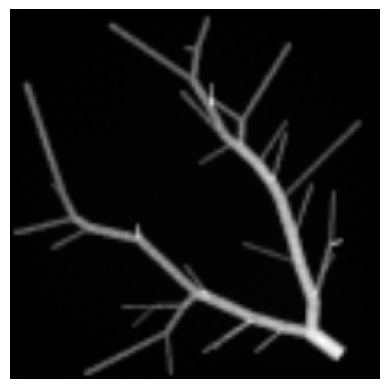

In [30]:

import matplotlib.pyplot as plt
imgr = x_recon_high.squeeze()
imgr = (imgr + 1) / 2   # map [-1,1] -> [0,1]
imgr = imgr.clamp(0,1).numpy()

plt.imshow(imgr, cmap='gray')
plt.axis('off')
plt.show()

## DDPM SAMPLING OF FEW IMAGES

Y_full shape: torch.Size([100, 1, 100, 188])




In [ ]:
import torch
import torch.nn.functional as F
import tqdm as tq
import matplotlib.pyplot as plt

device    = next(model.parameters()).device
low_sz    = 100
high_sz   = 256
eta       = 1.0 

# ------------ SCHEDULE ------------
T = config.diffusion.num_diffusion_timesteps
beta_schedule = config.diffusion.beta_schedule
beta_start    = config.diffusion.beta_start
beta_end      = config.diffusion.beta_end

betas_np = get_beta_schedule(
    beta_schedule=beta_schedule,
    beta_start=beta_start,
    beta_end=beta_end,
    num_diffusion_timesteps=T,
)
betas     = torch.from_numpy(betas_np).float().to(device)
alphas    = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

t_list = list(range(T-1, -1, -1))    


Y_full = y.to(device)           
print("Y_full shape:", Y_full.shape) 

B = Y_full.shape[0]
num_samples =  B
#num_samples =  5
assert num_samples > 0, "No measurements available: Y_full batch size is 0."

A = A.to(device)
m, n = A.shape
assert n == low_sz * low_sz

lam     = 0.999999995
I_n     = torch.eye(n, device=device)
ATA_inv = torch.inverse(lam * (A.T @ A) + (1.0 - lam) * I_n)

final_recons = []

model.eval()
with torch.no_grad():
    for i in range(num_samples):
        # pick i-th measurement
        y_i    = Y_full[i:i+1]             
        y_flat = y_i.view(1, -1)           

        
        x_high = torch.randn(1, 1, high_sz, high_sz, device=device)

        for t_idx in tq.tqdm(
            t_list,
            desc=f"(meas. consistency + denoising) sample {i}",
            leave=False,
        ):
             
            x_prev, x0_hat = ddpm_reverse_step(
                x_t       = x_high,
                t_idx     = t_idx,
                model     = model,
                betas     = betas,
                alpha_bar = alpha_bar,
                clip_denoised = True,
            )   
            x_low = F.interpolate(
                x0_hat,
                size=(low_sz, low_sz),
                mode="bilinear",
                align_corners=False,
            )    
            flat_x = x_low.view(1, -1)
            term_p = (1.0 - lam) * flat_x
            term_d = lam * (A.T @ y_flat.T).T
            flat_x = (ATA_inv @ (term_p + term_d).T).T
            x_low  = flat_x.view_as(x_low)         
                  
            flat_x = x_low.view(1, -1)                  # [1, n]
            Ax     = flat_x @ A.T                       # [1, m]
            resid  = Ax - y_flat                        # [1, m]
            grad   = (A.T @ resid.T).view_as(x_low)     
            x_low  = (x_low - eta * grad).clamp(0, 1)            
            x_high = F.interpolate(
                x_low,
                size=(high_sz, high_sz),
                mode="bilinear",
                align_corners=False,
            )

            

            
        final_recons.append(x0_hat.detach().cpu())


fig, axes = plt.subplots(1, num_samples, figsize=(4*num_samples, 4))
if num_samples == 1:
    axes = [axes]

for i in range(num_samples):
    img = final_recons[i].squeeze()
    img = ((img + 1) / 2).clamp(0, 1).numpy()  

    ax = axes[i]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Sample {i} – last refined x₀")
    ax.axis("off")

plt.tight_layout()
plt.show()


## METRIC COMPUTATION

In [ ]:
pip install torchmetrics lpips


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.8 MB/s eta 0:00:00
  Using cached typing_extensions-4.13.2-py3-none-any.whl (45 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-scheduler 2.10.0 requires fsspec<=2024.10.0,>=2023.6.0, but you have fsspec 2022.8.2 which is incompatible.
jupyter-scheduler 2.10.0 requires pytz<=2024.2,>=2023.3, but you have pytz 2022.4 which is incompatible.
jupyter-scheduler 2.10.0 requires sqlalchemy<3,>=2.0, but you have sqlalchemy 1.4.41 which is incompatible.
huggingface-hub 0.28.0 requires fsspec>=2023.5.0, but you have fsspec 2022.8.2 which is incompatible.
datasets 3.1.0 requires fsspec[http]<=2024.9.0,>=2023.1.0, but you have fsspec 2022.8.2 which is incompatible.
datasets 3.1.0 requires requests>=2.32.2, but you have reque

In [ ]:
import torch
import torch.nn.functional as F
import lpips

# LPIPS network (expects N,3,H,W in [-1,1])
loss_fn_lpips = lpips.LPIPS(net='vgg').to(device)
loss_fn_lpips.eval()

lpips_vals = []

num_eval = len(final_recons)   

for i in range(num_eval):
    #
    gt_t = GT_test[i].to(device)          
    if gt_t.ndim == 3:
        gt_t = gt_t.unsqueeze(0)          
    elif gt_t.ndim == 2:
        gt_t = gt_t.unsqueeze(0).unsqueeze(0)  

    
    recon_hr_t = final_recons[i].to(device)       
    recon_lr_t = F.interpolate(
        recon_hr_t,
        size=(gt_t.shape[-2], gt_t.shape[-1]),
        mode='bilinear',
        align_corners=False
    )                                          

    
    gt_min = gt_t.amin(dim=(-2, -1), keepdim=True)
    gt_max = gt_t.aman = gt_t.amax(dim=(-2, -1), keepdim=True)
    gt_norm = (gt_t - gt_min) / (gt_max - gt_min + 1e-12)
    recon_min = recon_lr_t.amin(dim=(-2, -1), keepdim=True)
    recon_max = recon_lr_t.amax(dim=(-2, -1), keepdim=True)
    recon_norm = (recon_lr_t - recon_min) / (recon_max - recon_min + 1e-12)

    gt_lp   = (gt_norm * 2.0 - 1.0).clamp(-1, 1)
    recon_lp = (recon_norm * 2.0 - 1.0).clamp(-1, 1)    
    gt_lp_3   = gt_lp.repeat(1, 3, 1, 1)       
    recon_lp_3 = recon_lp.repeat(1, 3, 1, 1)   

    
    lpips_val = loss_fn_lpips(recon_lp_3, gt_lp_3).item()
    lpips_vals.append(lpips_val)

    print(f"Sample {i}: LPIPS = {lpips_val:.4f}")

print("\nAverage LPIPS over", num_eval, "samples:",
      f"{sum(lpips_vals)/len(lpips_vals):.4f}")


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/700045831/.local/lib/python3.8/site-packages/lpips/weights/v0.1/vgg.pth
Sample 0: LPIPS = 0.0166
Sample 1: LPIPS = 0.0186
Sample 2: LPIPS = 0.0138
Sample 3: LPIPS = 0.0076
Sample 4: LPIPS = 0.0099
Sample 5: LPIPS = 0.0210
Sample 6: LPIPS = 0.0127
Sample 7: LPIPS = 0.0106
Sample 8: LPIPS = 0.0099
Sample 9: LPIPS = 0.0129
Sample 10: LPIPS = 0.0100
Sample 11: LPIPS = 0.0124
Sample 12: LPIPS = 0.0194
Sample 13: LPIPS = 0.0229
Sample 14: LPIPS = 0.0339
Sample 15: LPIPS = 0.0072
Sample 16: LPIPS = 0.0112
Sample 17: LPIPS = 0.0174
Sample 18: LPIPS = 0.0109
Sample 19: LPIPS = 0.0196
Sample 20: LPIPS = 0.0101
Sample 21: LPIPS = 0.0126
Sample 22: LPIPS = 0.0130
Sample 23: LPIPS = 0.0100
Sample 24: LPIPS = 0.0112
Sample 25: LPIPS = 0.0154
Sample 26: LPIPS = 0.0163
Sample 27: LPIPS = 0.0144
Sample 28: LPIPS = 0.0128
Sample 29: LPIPS = 0.0152
Sample 30: LPIPS = 0.0161
Sample 31: LPIPS = 0.0106
Sample 32

In [ ]:
import torch.nn.functional as F
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

psnr_vals = []
ssim_vals = []

num_eval = len(final_recons)   

for i in range(num_eval):
    
    gt_t = GT_test[i].to(device)         
    if gt_t.ndim == 3:
        gt_t = gt_t.unsqueeze(0)          
    elif gt_t.ndim == 2:
        gt_t = gt_t.unsqueeze(0).unsqueeze(0)  

    
    recon_hr_t = final_recons[i].to(device)      
    recon_lr_t = F.interpolate(
        recon_hr_t,
        size=(gt_t.shape[-2], gt_t.shape[-1]),
        mode='bilinear',
        align_corners=False
    )                                          
    
    gt_np    = gt_t.squeeze().cpu().numpy()       
    recon_np = recon_lr_t.squeeze().cpu().numpy() 
    gt_norm    = (gt_np - gt_np.min()) / (gt_np.max() - gt_np.min() + 1e-12)
    recon_norm = (recon_np - recon_np.min()) / (recon_np.max() - recon_np.min() + 1e-12)
   
    drange = gt_norm.max() - gt_norm.min()
    if drange == 0:   
        drange = 1.0

    psnr_val = peak_signal_noise_ratio(gt_norm, recon_norm, data_range=drange)
    ssim_val = structural_similarity(
        gt_norm,
        recon_norm,
        data_range=drange,
        win_size=11,
        channel_axis=None,   
    )

    psnr_vals.append(psnr_val)
    ssim_vals.append(ssim_val)

    print(f"Sample {i}: PSNR = {psnr_val:.2f} dB, SSIM = {ssim_val:.4f}")


print("\nAverages over", num_eval, "samples:")
print(f"Mean PSNR = {sum(psnr_vals)/len(psnr_vals):.2f} dB")
print(f"Mean SSIM = {sum(ssim_vals)/len(ssim_vals):.4f}")


Sample 0: PSNR = 36.68 dB, SSIM = 0.9226
Sample 1: PSNR = 37.69 dB, SSIM = 0.9456
Sample 2: PSNR = 34.43 dB, SSIM = 0.9152
Sample 3: PSNR = 37.85 dB, SSIM = 0.9431
Sample 4: PSNR = 36.03 dB, SSIM = 0.9236
Sample 5: PSNR = 36.62 dB, SSIM = 0.9317
Sample 6: PSNR = 36.25 dB, SSIM = 0.9340
Sample 7: PSNR = 35.92 dB, SSIM = 0.9209
Sample 8: PSNR = 38.56 dB, SSIM = 0.9337
Sample 9: PSNR = 33.41 dB, SSIM = 0.8992
Sample 10: PSNR = 38.80 dB, SSIM = 0.9388
Sample 11: PSNR = 36.02 dB, SSIM = 0.9221
Sample 12: PSNR = 37.07 dB, SSIM = 0.9261
Sample 13: PSNR = 38.44 dB, SSIM = 0.9467
Sample 14: PSNR = 35.59 dB, SSIM = 0.9157
Sample 15: PSNR = 38.30 dB, SSIM = 0.9388
Sample 16: PSNR = 35.35 dB, SSIM = 0.9190
Sample 17: PSNR = 37.17 dB, SSIM = 0.9291
Sample 18: PSNR = 39.14 dB, SSIM = 0.9437
Sample 19: PSNR = 38.01 dB, SSIM = 0.9336
Sample 20: PSNR = 40.88 dB, SSIM = 0.9483
Sample 21: PSNR = 33.70 dB, SSIM = 0.8919
Sample 22: PSNR = 39.79 dB, SSIM = 0.9440
Sample 23: PSNR = 36.20 dB, SSIM = 0.9151
Sa